# **Курсовая работа** <br>  Выполнила: Яковенко Арина ПМ23-4

# <hr>**Машинное обучение в задачах распознавания темы текста**. <dt> Датасет: [AG News Classification Dataset](https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset)

In [200]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from yellowbrick.model_selection import LearningCurve
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier
import xgboost as xgb

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import time
from collections import Counter
import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag

## <hr> Введение

Цель работы — разработать и сравнить разные модели машинного обучения, чтобы достичь высокой точности в классификации. Текстовая классификация важна для многих реальных приложений, таких как организация больших объёмов текстовых данных, фильтрация спама, анализ настроений и работа чат-ботов. Она делает информацию более доступной и управляемой, что особенно актуально в современном мире, где данных становится всё больше.

## <hr> 1. Выбрать набор данных для анализа в соответствии с выбранной темой курсовой работы. Описать этот набор и решаемую задачу.

### Выбор датасета

Для выполнения своей курсовой работы я выбрала датасет <u>[`AG News Classification Dataset`](https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset)</u> на Kaggle. Причиной выбора именного этого датасета из множества других доступных является то, что `AG News Classification Dataset` представляет собой коллекцию новостных статей, разделенных на 4 категории: `World`, `Sports`, `Business`, `Sci/Tech`. Выбранный датасет идеально подходит для задачи классификации текста по темам, так как содержит достаточно большой объем данных и сбалансированное распределение классов.

### Описание датасета

- Источник: Датасет собран из новостных источников и часто используется в задачах обработки естественного языка (NLP) как бенчмарк для классификации текста.
- Объем: Датасет предоставлен в виде двух файлов:
  - `train.csv`: 120,000 записей (обучающий набор).
  - `test.csv`: 7,600 записей (тестовый набор).
- Структура: Каждая запись содержит:
  - `Class Index`: метка категории (1 — World, 2 — Sports, 3 — Business, 4 — Sci/Tech).
  - `Title`: заголовок новости.
  - `Description`: краткое описание новости.

### Решаемая задача

Задача состоит в классификации текста по темам (многоклассовая классификация). На основе заголовка и описания новости необходимо предсказать одну из четырех категорий: `World`, `Sports`, `Business` или `Sci/Tech`. Для оценки качества моделей будут использованы метрики `accuracy` (общая точность), а также `precision`, `recall` и `F1-score` для анализа качества классификации по каждому классу.

### Загрузка датасета

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

Датасет AG News изначально предоставлен в виде двух файлов: `train.csv` (120,000 записей) и `test.csv` (7,600 записей). Для выполнения требования курсовой работы о самостоятельном разделении данных, файлы были объединены в один набор (127,600 записей).

In [3]:
combined_df = pd.concat([train_df, test_df], ignore_index=True)

print("Размер объединенного датасета:", combined_df.shape)
print("Первые строки объединенного датасета:")
print(combined_df.head())

Размер объединенного датасета: (127600, 3)
Первые строки объединенного датасета:
   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  


## <hr> 2. Провести предварительный анализ и очистку данных. Этот этап включает в себя вывод информации о количественных характеристиках датасета, информацию об отсутствующих значениях, характеристиках и физическом смысле каждого атрибута данных, его значимости для предсказания целевой переменной, вывод нескольких точек данных для иллюстрации структуры данных.

Размер датасета:

In [4]:
combined_df.shape

(127600, 3)

Информация о столбцах:

In [5]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127600 entries, 0 to 127599
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  127600 non-null  int64 
 1   Title        127600 non-null  object
 2   Description  127600 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.9+ MB


Имеем, что `Class Index` является целевой переменной

Вывод первых 5 строк:

In [6]:
combined_df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


Проверка на пропущенные значения:

In [7]:
combined_df.isnull().sum()

Class Index    0
Title          0
Description    0
dtype: int64

Делаем вывод, что пропущенные значения <u>отсуствуют.

Проверка на дубликаты:

In [8]:
combined_df.duplicated().sum()

0

Дубликаты <u>отсуствуют.

Таким образом, датасет содержит `127,600` записей и `3` столбца (`Class Index`, `Title`, `Description`). Типы данных корректны, пропуски и дубликаты отсуствуют, классы сбалансированны.

### Характеристики и физический смысл атрибутов
- `Class Index`: Целевая переменная, принимает значения от 1 до 4, обозначающие категории (1 — World, 2 — Sports, 3 — Business, 4 — Sci/Tech). Это номинальная шкала, основа для классификации.
- `Title`: Заголовок новости, текстовый атрибут. Содержит ключевые слова, отражающие тему, что делает его значимым для предсказания.
- `Description`: Краткое описание новости, текстовый атрибут. Дополняет заголовок, предоставляя дополнительный контекст, и может помочь различить похожие темы.

### Значимость атрибутов для предсказания
- `Class Index`: Определяет целевую категорию, ключевой атрибут для задачи.
- `Title`: Высоко значим, так как заголовки часто содержат сжатую информацию о теме (например, "Football Match" для Sports).
- `Description`: Значим, но может содержать больше общего текста или шума, что требует тщательной очистки для выделения релевантной информации.
Оба текстовых атрибута будут обработаны отдельно, чтобы сохранить их индивидуальный вклад в классификацию.

### Визуализация

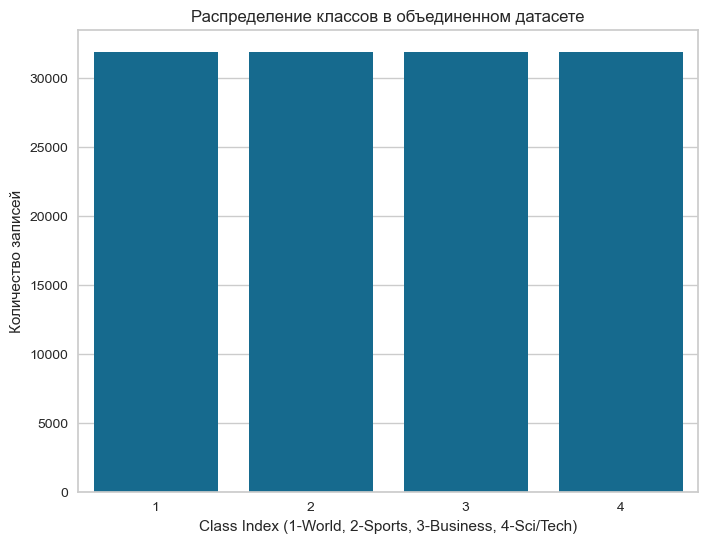

In [9]:
# Визуализация распределения классов
plt.figure(figsize=(8, 6))
sns.countplot(x='Class Index', data=combined_df)
plt.title('Распределение классов в объединенном датасете')
plt.xlabel('Class Index (1-World, 2-Sports, 3-Business, 4-Sci/Tech)')
plt.ylabel('Количество записей')
plt.show()

### Очистка текста

In [10]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /Users/arinchees/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/arinchees/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/arinchees/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/arinchees/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

Текст будет обработан с использованием:
- приведение к нижнему регистру;
- удаление сложных HTML-остатков, чисел, дефисов и лишних символов;

Добавлены кастомные стоп-слова (`reuters`, `ap`, `afp`, `u`, `say`, `said`, `ltbgt`, `inc`, `corp`) для исключения специфического шума новостных текстов. Также был применен `POS-tagging` для исключения имен собственных (`NNP`, `NNPS`), а также лемматизация.

In [11]:
stop_words = list(stopwords.words('english'))
custom_stop_words = ['reuters', 'ap', 'afp', 'u', 'say', 'said', 'ltbgt', 'ltbgtltbgt', 'inc', 'corp']
stop_words.extend(custom_stop_words)

In [12]:
lemmatizer = WordNetLemmatizer()
def clean_text(text):
    text = re.sub(r'targetstocksquickinfo[a-z]*', '', text)
    text = re.sub(r'<[^>]+>|ltbgt[a-z]*', '', text)
    text = re.sub(r'&[^;\s]+;', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[-_]+', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def process_text(text):
    cleaned_text = clean_text(text)
    sentences = sent_tokenize(cleaned_text)
    words = []
    for sentence in sentences:
        tokens = word_tokenize(sentence)
        tagged = pos_tag(tokens)
        for word, pos in tagged:
            if word not in stop_words and len(word) >= 2 and pos not in ['NNP', 'NNPS']:
                words.append(lemmatizer.lemmatize(word))
    return ' '.join(words)

In [13]:
%%time
combined_df['Title'] = combined_df['Title'].apply(process_text)
combined_df['Description'] = combined_df['Description'].apply(process_text)

CPU times: user 2min 4s, sys: 1.61 s, total: 2min 5s
Wall time: 2min 6s


Время обработки составило 2 минуты 5 секунд, что связано со сложностью обработки, но данный результат приемлем для такого объема данных.

In [14]:
combined_df.head()

,Class Index,Title,Description
0,3,wall st bear claw back black,short seller wall street dwindlingband ultra c...
1,3,carlyle look toward commercial aerospace,private investment firm carlyle groupwhich rep...
2,3,oil economy cloud stock outlook,soaring crude price plus worriesabout economy ...
3,3,iraq halt oil export main southern pipeline,authority halted oil exportflows main pipeline...
4,3,oil price soar time record posing new menace u...,tearaway world oil price toppling record strai...


### Преобразование атрибутов в числовые признаки

Объединяем текста для векторизации:

In [15]:
combined_df['Text'] = combined_df['Title'] + ' ' + combined_df['Description']

In [16]:
X = combined_df['Text']
y = combined_df['Class Index']

In [17]:
tfidf = TfidfVectorizer(min_df=5, stop_words=['gazpromneft', 'saha', 'wwi', 'hampden', 'sahib', 'throughput', 'mulholland', 'cutcliffe', 'mario', 'raef', 'rae', 'arjen', 'clifford', 'zeus'])
X_transformed = tfidf.fit_transform(X)

Размер результирующей матрицы признаков, где первое число — количество записей, а второе число — число уникальных слов после очистки.

In [18]:
X_transformed.shape

(127600, 23357)

## <hr> 4. Провести описательный анализ данных. Сделать выводы. Этот этап включает в себя определение шкалы измерения каждого признака, выявление аномальных значений, визуализацию распределения каждого признака, при необходимости - проверка на нормальность, построение кореллограмм и совместных распределений каждого признака с целевой переменной, выявление коррелированных признаков и признаков, не несущих информации для данной задачи.

In [19]:
combined_df.shape

(127600, 4)

In [20]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127600 entries, 0 to 127599
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  127600 non-null  int64 
 1   Title        127600 non-null  object
 2   Description  127600 non-null  object
 3   Text         127600 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.9+ MB


Шкала измерения:
- `Class Index` - категориальная
- `Title`, `Description` - номинальные текстовые данные
- `Title Length`, `Description Length` - количественные (дискретные)

Распределение классов:

In [21]:
combined_df['Class Index'].value_counts()

Class Index
3    31900
4    31900
2    31900
1    31900
Name: count, dtype: int64

Распределение <u>сбалансированно</u>: по 31,900 записей на класс

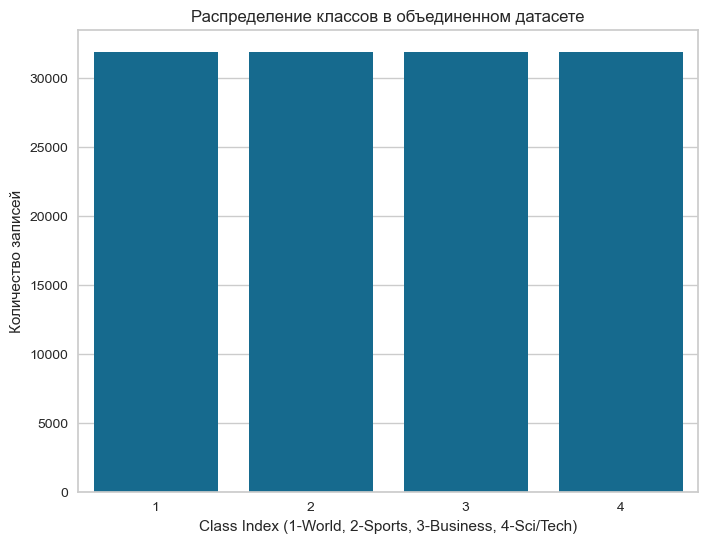

In [22]:
# Визуализация распределения классов
plt.figure(figsize=(8, 6))
sns.countplot(x='Class Index', data=combined_df)
plt.title('Распределение классов в объединенном датасете')
plt.xlabel('Class Index (1-World, 2-Sports, 3-Business, 4-Sci/Tech)')
plt.ylabel('Количество записей')
plt.show()

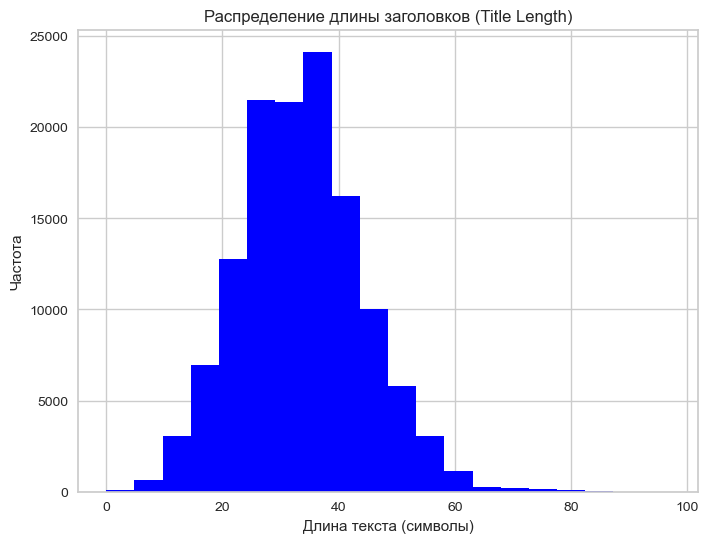

Статистики длины заголовков:
count    127600.000000
mean         33.560078
std          10.592353
min           0.000000
25%          27.000000
50%          33.000000
75%          40.000000
max          97.000000
Name: Title Length, dtype: float64


In [23]:
# Распределение Title Length
combined_df['Title Length'] = combined_df['Title'].str.len()
plt.figure(figsize=(8, 6))
plt.hist(combined_df['Title Length'], bins=20, color='blue')
plt.title('Распределение длины заголовков (Title Length)')
plt.xlabel('Длина текста (символы)')
plt.ylabel('Частота')
plt.show()
print("Статистики длины заголовков:")
print(combined_df['Title Length'].describe())

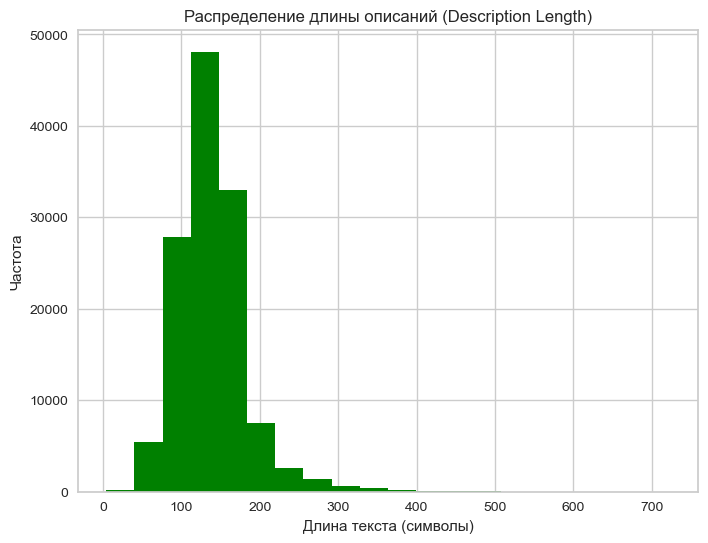

Статистики длины описаний:
count    127600.000000
mean        138.303315
std          45.928620
min           4.000000
25%         110.000000
50%         135.000000
75%         159.000000
max         723.000000
Name: Description Length, dtype: float64


In [24]:
# Распределение Description Length
combined_df['Description Length'] = combined_df['Description'].str.len()
plt.figure(figsize=(8, 6))
plt.hist(combined_df['Description Length'], bins=20, color='green')
plt.title('Распределение длины описаний (Description Length)')
plt.xlabel('Длина текста (символы)')
plt.ylabel('Частота')
plt.show()
print("Статистики длины описаний:")
print(combined_df['Description Length'].describe())

### Анализ длины текстов

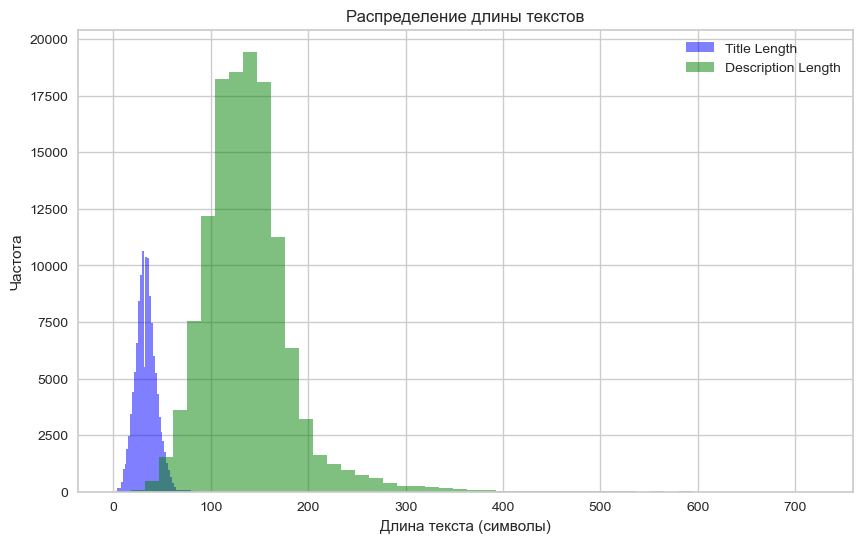

In [25]:
combined_df['Title Length'] = combined_df['Title'].str.len()
combined_df['Description Length'] = combined_df['Description'].str.len()
plt.figure(figsize=(10, 6))
plt.hist(combined_df['Title Length'], bins=50, alpha=0.5, label='Title Length', color='blue')
plt.hist(combined_df['Description Length'], bins=50, alpha=0.5, label='Description Length', color='green')
plt.title('Распределение длины текстов')
plt.xlabel('Длина текста (символы)')
plt.ylabel('Частота')
plt.legend()
plt.show()

Статистики длины заголовков:

In [26]:
combined_df['Title Length'].describe()

count    127600.000000
mean         33.560078
std          10.592353
min           0.000000
25%          27.000000
50%          33.000000
75%          40.000000
max          97.000000
Name: Title Length, dtype: float64

Статистики длины описаний:

In [27]:
combined_df['Description Length'].describe()

count    127600.000000
mean        138.303315
std          45.928620
min           4.000000
25%         110.000000
50%         135.000000
75%         159.000000
max         723.000000
Name: Description Length, dtype: float64

### Анализ частотности слов

Объединяем текст из Title и Description для анализа частотности. Делаем это только для анализа, сами столбцы останутся раздельными

In [28]:
all_titles = ' '.join(combined_df['Title'].dropna())
all_descriptions = ' '.join(combined_df['Description'].dropna())

In [29]:
title_words = re.findall(r'\b\w{2,}\b', all_titles)
description_words = re.findall(r'\b\w{2,}\b', all_descriptions)

In [30]:
df_title_words = pd.DataFrame(title_words, columns=['word']).groupby('word').size().reset_index(name='count')
df_title_words = df_title_words.sort_values('count', ascending=False)

df_description_words = pd.DataFrame(description_words, columns=['word']).groupby('word').size().reset_index(name='count')
df_description_words = df_description_words.sort_values('count', ascending=False)

Фильтруем слова по минимальной частоте (я выбрала не менее 5 раз, тк это золотая середина: достаточно, чтобы отсеять случайный "мусор", но не слишком строго, чтобы не потерять интересные, но не самые популярные термины/слова)

In [31]:
min_freq = 5
df_title_words = df_title_words[df_title_words['count'] >= min_freq]
df_description_words = df_description_words[df_description_words['count'] >= min_freq]

In [32]:
df_title_words = df_title_words[~df_title_words['word'].isin(stop_words)]
df_description_words = df_description_words[~df_description_words['word'].isin(stop_words)]

10 <u>самых</u> популярных слов в Title и Description:

In [33]:
pd.concat([df_title_words.head(10).reset_index(drop=True), df_description_words.head(10).reset_index(drop=True)], axis=1)

,word,count,word,count
0,new,4304,new,18351
1,win,2756,year,14042
2,bb,2715,company,10155
3,oil,2672,two,9803
4,iraq,2437,first,9114
5,microsoft,2428,one,7943
6,update,2283,world,7876
7,stock,2018,monday,7874
8,deal,1913,wednesday,7734
9,price,1897,tuesday,7725


Наиболее часто встречающиеся слова в `Title` отражают ключевые темы новостей, такие как спорт (`win`, `game`), экономика (`oil`, `stock`, `price`) и политика (`iraq`).

Тем временем самые популярные слова в `Description`, включают общие термины и временные маркеры (`monday`, `tuesday`, `friday`), что логично для описаний, где часто указывают даты и последовательность событий.

10 <u>наименее</u> популярных слов в Title и Description:

In [34]:
pd.concat([df_title_words.tail(10).reset_index(drop=True), df_description_words.tail(10).reset_index(drop=True)], axis=1)

,word,count,word,count
0,cutcliffe,5,raef,5
1,distract,5,impede,5
2,arabiya,5,rae,5
3,chaotic,5,recycled,5
4,parkinson,5,arjen,5
5,playground,5,psychic,5
6,scorch,5,clifford,5
7,phoning,5,zeta,5
8,mario,5,explores,5
9,shutting,5,zeus,5


10 наименее популярных слов в `Title` содержат редкие, но осмысленные термины, связанные с конкретными контекстами (например, `parkinson`, `chaotic`), а также специфические слова (`mario`), которые могут быть связаны с уникальными новостями.

В `Description` менее употребляемыми словами также являются редкие описательные термины (`psychic`, `zeta`), но ещё содержатся специфические слова (`zeus`, `arjen`), которые могут быть географическими названиями или именами, не полностью исключенными фильтрацией.

### Визуализация

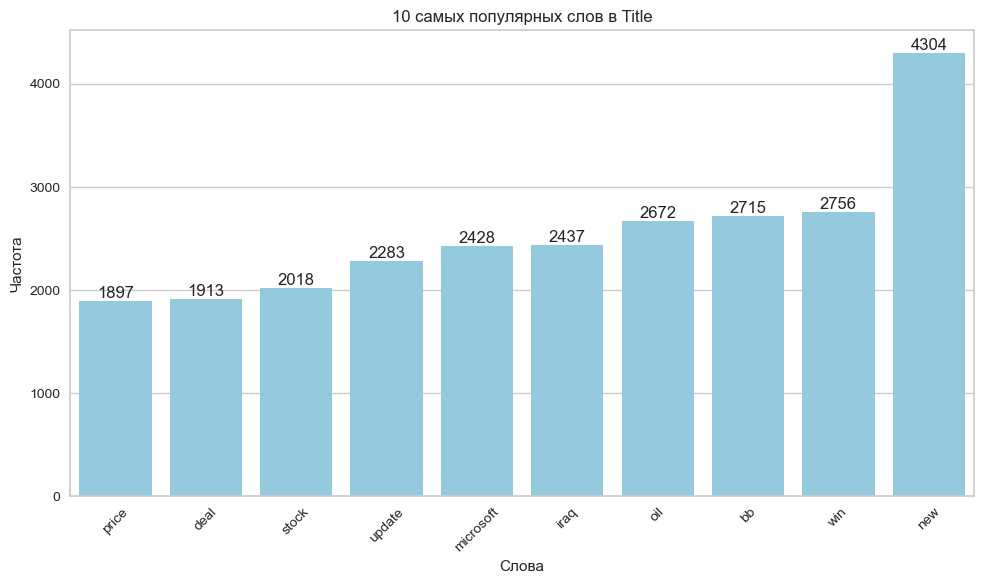

In [35]:
# 10 самых популярных слов в Title
plt.figure(figsize=(10, 6))
sns.barplot(data=df_title_words.head(10).sort_values('count'), x='word', y='count', color='skyblue')
plt.title('10 самых популярных слов в Title')
plt.xlabel('Слова')
plt.ylabel('Частота')
for i, v in enumerate(df_title_words.head(10).sort_values('count')['count']):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

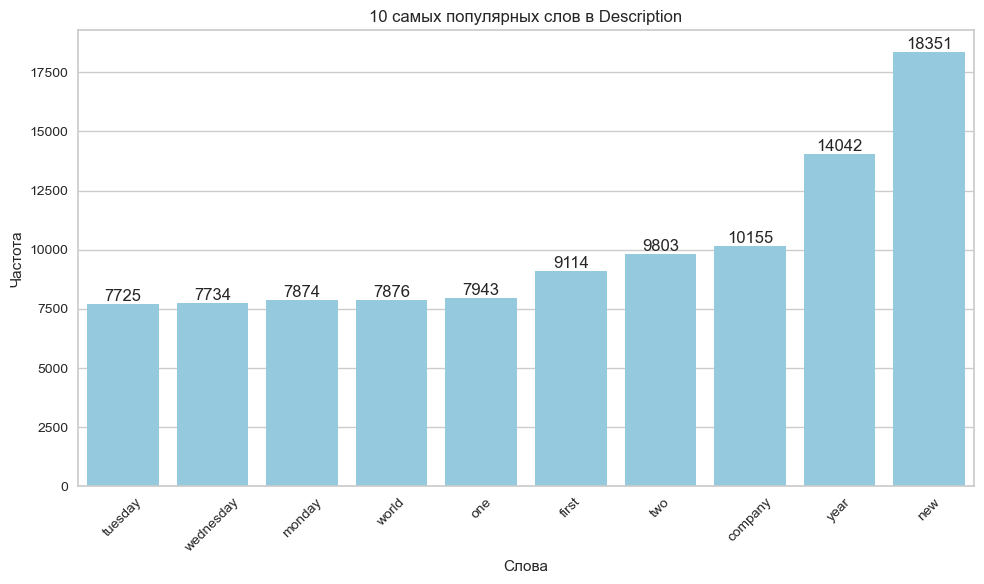

In [36]:
# 10 самых популярных слов в Description
plt.figure(figsize=(10, 6))
sns.barplot(data=df_description_words.head(10).sort_values('count'), x='word', y='count', color='skyblue')
plt.title('10 самых популярных слов в Description')
plt.xlabel('Слова')
plt.ylabel('Частота')
for i, v in enumerate(df_description_words.head(10).sort_values('count')['count']):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Проверка на аномалии

Количество аномально длинных заголовков:

In [37]:
outliers_title = combined_df[combined_df['Title Length'] > combined_df['Title Length'].quantile(0.99)]
print(len(outliers_title))

1052


Количество аномально длинных описаний:

In [38]:
outliers_desc = combined_df[combined_df['Description Length'] > combined_df['Description Length'].quantile(0.99)]
print(len(outliers_desc))

1261


Аномалии определены как тексты, превышающие 99-й процентиль.

## <hr> 5. Применить при необходимости к данным методы обучения без учителя: кластеризацию, понижение размерности и поиск аномалий. Сделать выводы.

Поскольку у нас 4 класса, попробуем кластеризовать данные на 4 кластера

In [39]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_transformed)
combined_df['Cluster'] = kmeans.labels_

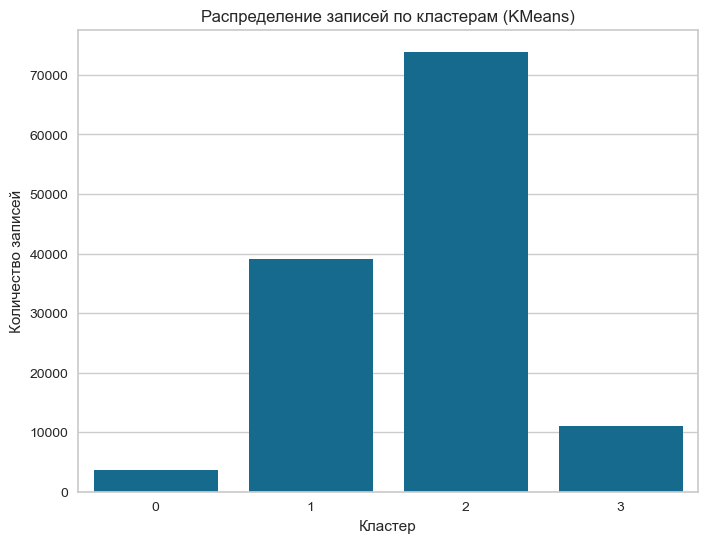

Распределение записей по кластерам:
Cluster
2    73897
1    39091
3    11012
0     3600
Name: count, dtype: int64


In [40]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Cluster', data=combined_df)
plt.title('Распределение записей по кластерам (KMeans)')
plt.xlabel('Кластер')
plt.ylabel('Количество записей')
plt.show()
print("Распределение записей по кластерам:")
print(combined_df['Cluster'].value_counts())

Кластеры получились неравномерными, что может указывать на сложность разделения текстовых данных.  

Сравнение кластеров с истинными метками:

In [41]:
cluster_class_cross = pd.crosstab(combined_df['Class Index'], combined_df['Cluster'])
cluster_class_cross

Cluster,0,1,2,3
Class Index,,,,
1,330,735,19958,10877
2,3,89,31789,19
3,3229,19023,9579,69
4,38,19244,12571,47


Тут кластеры частично соответствуют классам, но пересечения значительные. Это говорит о том, что тексты имеют пересекающиеся темы.

Для визуализации снизим размерность до 2 компонент

Использую TruncatedSVD вместо PCA для работы с разреженной TF-IDF матрицей, потому PCA работал некорректно из-за проблем с памятью.

In [42]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X_transformed)

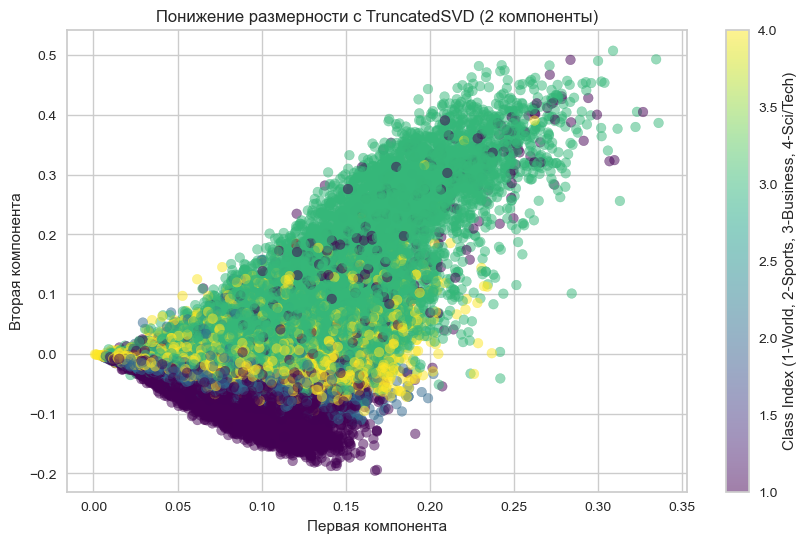

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(X_svd[:, 0], X_svd[:, 1], c=combined_df['Class Index'], cmap='viridis', alpha=0.5)
plt.title('Понижение размерности с TruncatedSVD (2 компоненты)')
plt.xlabel('Первая компонента')
plt.ylabel('Вторая компонента')
plt.colorbar(label='Class Index (1-World, 2-Sports, 3-Business, 4-Sci/Tech)')
plt.show()

Классы частично разделяются, но пересекаются, особенно между `Business` (3) и `Sci/Tech` (4). Это подтверждает сложность задачи и необходимость более сложных методов разделения.  

Объясненная дисперсия TruncatedSVD:

In [44]:
svd.explained_variance_ratio_.sum()

0.004927705335372714

Проверим на аномалии:

In [45]:
iso_forest = IsolationForest(contamination=0.01, random_state=42)
outliers = iso_forest.fit_predict(X_transformed)
combined_df['Outlier'] = outliers  # -1 для аномалий, 1 для нормальных записей

Количество аномалий:

In [46]:
(outliers == -1).sum()

1276

Количество аномалий совпадает с анализом длины текстов из задания 4 (аномально длинные записи).

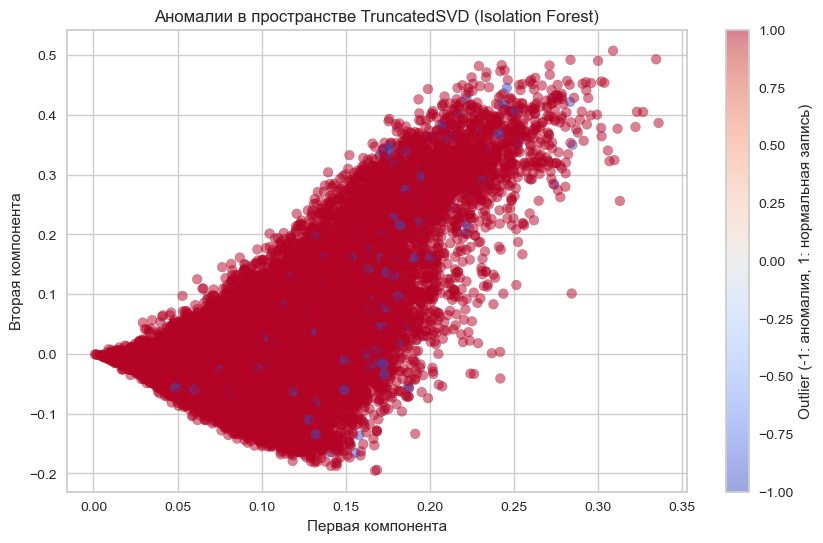

In [47]:
# Визуализация аномалий в пространстве SVD
plt.figure(figsize=(10, 6))
plt.scatter(X_svd[:, 0], X_svd[:, 1], c=combined_df['Outlier'], cmap='coolwarm', alpha=0.5)
plt.title('Аномалии в пространстве TruncatedSVD (Isolation Forest)')
plt.xlabel('Первая компонента')
plt.ylabel('Вторая компонента')
plt.colorbar(label='Outlier (-1: аномалия, 1: нормальная запись)')
plt.show()

Визуализация показала, что аномалии равномерно распределены, без явных кластеров аномалий.  

## <hr> 6. Разделить набор данных на обучающую и тестовую выборки. Обосновать количественные характеристики и метод разделения (временной, случайный, последовательный).


In [48]:
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, stratify=y, random_state=42)

In [49]:
X_train.shape, X_test.shape

((102080, 23357), (25520, 23357))

In [50]:
y_train.value_counts(), y_test.value_counts()

(Class Index
 2    25520
 3    25520
 4    25520
 1    25520
 Name: count, dtype: int64,
 Class Index
 1    6380
 3    6380
 2    6380
 4    6380
 Name: count, dtype: int64)

Получилось, что размер обучающей выборки равен 102,080, а размер тестовой выборки равен 25,520 записей. При распределении классов получили следующие результаты: 
- Обучающая выборка: по 25,520 записей на класс;  
- Тестовая выборка: по 6,380 записей на класс.

Эти результаты соотвествуют исходному распределению.

## <hr> 7. Обучить несколько моделей для решения выбранной задачи (для задач классификации - не менее 7 различных алгоритмов). Проанализировать результаты, сделать выводы. 

In [51]:
models = [
    LogisticRegression(n_jobs=-1, random_state=42, max_iter=1000),
    ComplementNB(),
    SGDClassifier(n_jobs=-1, random_state=42),
    RandomForestClassifier(n_jobs=-1, random_state=42),
    RidgeClassifier(random_state=42),
    KNeighborsClassifier(n_neighbors=10, n_jobs=-1),
    LinearSVC(dual='auto', random_state=42),
    MultinomialNB()
]

In [52]:
results = []
for model in models:
    model_name = model.__class__.__name__
    print(f"Модель: {model_name}")
    
    start_time = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    end_time = time.time()
    learning_time = end_time - start_time

    report = classification_report(y_test, y_pred, target_names=['World', 'Sports', 'Business', 'Sci/Tech'], output_dict=True)
    accuracy = report['accuracy']
    f1_macro = report['macro avg']['f1-score']
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Время обучения и предсказания: {learning_time:.2f} секунд")
    print(classification_report(y_test, y_pred, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))
    print()

    results.append({
        'name': model_name,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'time': learning_time
    })

Модель: LogisticRegression
Accuracy: 0.9127
Время обучения и предсказания: 3.86 секунд
              precision    recall  f1-score   support

       World       0.92      0.89      0.91      6380
      Sports       0.95      0.98      0.97      6380
    Business       0.88      0.89      0.88      6380
    Sci/Tech       0.89      0.89      0.89      6380

    accuracy                           0.91     25520
   macro avg       0.91      0.91      0.91     25520
weighted avg       0.91      0.91      0.91     25520


Модель: ComplementNB
Accuracy: 0.9077
Время обучения и предсказания: 0.02 секунд
              precision    recall  f1-score   support

       World       0.92      0.89      0.91      6380
      Sports       0.93      0.99      0.96      6380
    Business       0.89      0.86      0.87      6380
    Sci/Tech       0.89      0.88      0.89      6380

    accuracy                           0.91     25520
   macro avg       0.91      0.91      0.91     25520
weighted avg    

In [53]:
df_models = pd.DataFrame(results)
df_models = df_models.sort_values('accuracy', ascending=False).reset_index(drop=True)
df_models

,name,accuracy,f1_macro,time
0,RidgeClassifier,0.917320,0.917115,0.766107
1,LinearSVC,0.913480,0.913305,4.166838
2,LogisticRegression,0.912735,0.912534,3.859087
3,SGDClassifier,0.911755,0.911416,0.122563
4,ComplementNB,0.907680,0.907157,0.018218
5,MultinomialNB,0.906113,0.905901,0.026123
6,KNeighborsClassifier,0.903683,0.903471,55.816024
7,RandomForestClassifier,0.891418,0.890979,18.259266


Все модели демонстрируют хорошую точность (89–91%), что подтверждает качество подготовки данных. `RidgeClassifier` выделяется как лучшая модель с точностью `0.9173` и временем 0.77 секунды. `SGDClassifier` имеет хорошие результаты: скорость 0.13 сек и высокая точность `0.9118`. `RandomForestClassifier` и `KNeighborsClassifier` показали худшие результаты по точности и времени. Для дальнейшей работы будут выбраны модели `RidgeClassifier` или `SGDClassifier`.

## <hr> 8. Выбрать наиболее перспективную модель для решения поставленной задачи. Изменить гиперпараметры модели. Предпочтительно, провести Grid Search. Найти оптимальные гиперпараметры. 

В прошлом задании, обучив 7 моделей и получив их результаты, были отобраны лучшие модели, а именно `RidgeClassifier` и `SGDClassifier`. Исходя из того, что у `RidgeClassifier` более высокая `accuracy` и `f1-macro`, то ее и выберем для дальнейшего использования в поставленной задаче

In [105]:
base_model = RidgeClassifier(random_state=42)

Проведем `Grid Search` с гиперпараметрами: 
```python 
alpha=[0.01, 0.1, 1.0, 10.0, 100.0], 
solver=['auto', 'lsqr', 'sparse_cg'], 
tol=[1e-5, 1e-4, 1e-3, 1e-2]`. 
```

In [106]:
param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0], 
    'solver': ['auto', 'lsqr', 'sparse_cg'],  
    'tol': [1e-5, 1e-4, 1e-3, 1e-2]  
}

In [107]:
grid_model = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=1,  
    verbose=2  
)

In [108]:
start_time = time.time()
grid_model.fit(X_train, y_train)
end_time = time.time()
search_time = end_time - start_time

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END .................alpha=0.01, solver=auto, tol=1e-05; total time=   3.8s
[CV] END .................alpha=0.01, solver=auto, tol=1e-05; total time=   3.8s
[CV] END .................alpha=0.01, solver=auto, tol=1e-05; total time=   3.8s
[CV] END .................alpha=0.01, solver=auto, tol=1e-05; total time=   3.8s
[CV] END .................alpha=0.01, solver=auto, tol=1e-05; total time=   3.8s
[CV] END ................alpha=0.01, solver=auto, tol=0.0001; total time=   2.4s
[CV] END ................alpha=0.01, solver=auto, tol=0.0001; total time=   2.5s
[CV] END ................alpha=0.01, solver=auto, tol=0.0001; total time=   2.4s
[CV] END ................alpha=0.01, solver=auto, tol=0.0001; total time=   2.6s
[CV] END ................alpha=0.01, solver=auto, tol=0.0001; total time=   2.5s
[CV] END .................alpha=0.01, solver=auto, tol=0.001; total time=   1.2s
[CV] END .................alpha=0.01, solver=au

In [110]:
print(f"Время выполнения Grid Search: {search_time:.2f} секунд")
print("Лучшие гиперпараметры:", grid_model.best_params_)
print("Лучшая кросс-валидационная точность:", grid_model.best_score_)

Время выполнения Grid Search: 223.93 секунд
Лучшие гиперпараметры: {'alpha': 1.0, 'solver': 'auto', 'tol': 0.01}
Лучшая кросс-валидационная точность: 0.9143318965517242


In [111]:
best_model = grid_model.best_estimator_
best_model.fit(X_train, y_train)
y_pred_optimized = best_model.predict(X_test)

In [112]:
print(classification_report(y_test, y_pred_optimized, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

              precision    recall  f1-score   support

       World       0.93      0.90      0.92      6380
      Sports       0.96      0.99      0.97      6380
    Business       0.88      0.89      0.89      6380
    Sci/Tech       0.90      0.89      0.89      6380

    accuracy                           0.92     25520
   macro avg       0.92      0.92      0.92     25520
weighted avg       0.92      0.92      0.92     25520



In [113]:
base_model_default = RidgeClassifier(random_state=42) 
base_model_default.fit(X_train, y_train)
y_pred_base = base_model_default.predict(X_test)

print("Метрики на тестовой выборке для исходной модели (alpha=1.0, solver='auto', tol=1e-4):")
print(classification_report(y_test, y_pred_base, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

Метрики на тестовой выборке для исходной модели (alpha=1.0, solver='auto', tol=1e-4):
              precision    recall  f1-score   support

       World       0.93      0.90      0.92      6380
      Sports       0.96      0.99      0.97      6380
    Business       0.88      0.89      0.89      6380
    Sci/Tech       0.90      0.90      0.90      6380

    accuracy                           0.92     25520
   macro avg       0.92      0.92      0.92     25520
weighted avg       0.92      0.92      0.92     25520



Если сравнивать с исходной моделью, то исходная `accuracy = 0.92`, `macro-F1 = 0.92`, а в оптимизированной `accuracy = 0.92`, `macro-F1 = 0.92`. <br> Выходит, что улучшения отсутствуют, потому что `Sci/Tech recall` снизился с 0.90 до 0.89.  


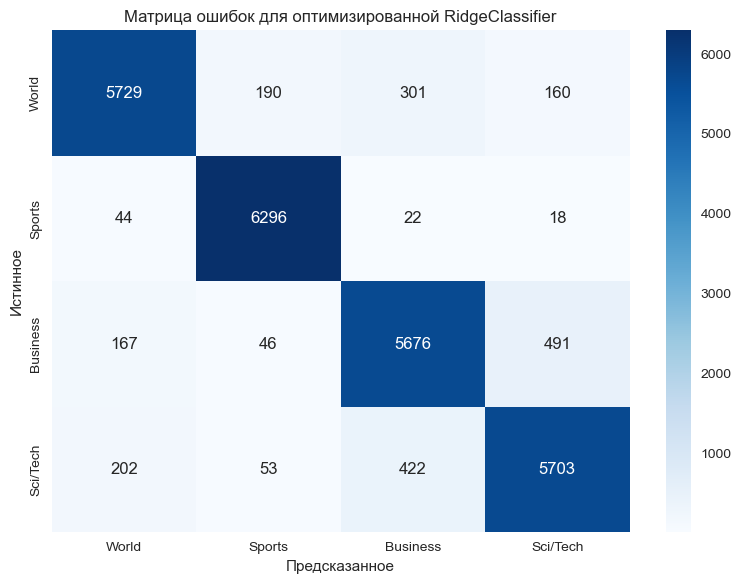

In [114]:
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues', xticklabels=['World', 'Sports', 'Business', 'Sci/Tech'], yticklabels=['World', 'Sports', 'Business', 'Sci/Tech'])
plt.xlabel('Предсказанное')
plt.ylabel('Истинное')
plt.title('Матрица ошибок для оптимизированной RidgeClassifier')
plt.tight_layout()
plt.show()

Матрица ошибок для оптимизированной модели показала высокую точность, что наибольшие ошибки между `Business` и `Sci/Tech` (совпадает с результатами исходной модели) и что ошибки между другими классами минимальны.

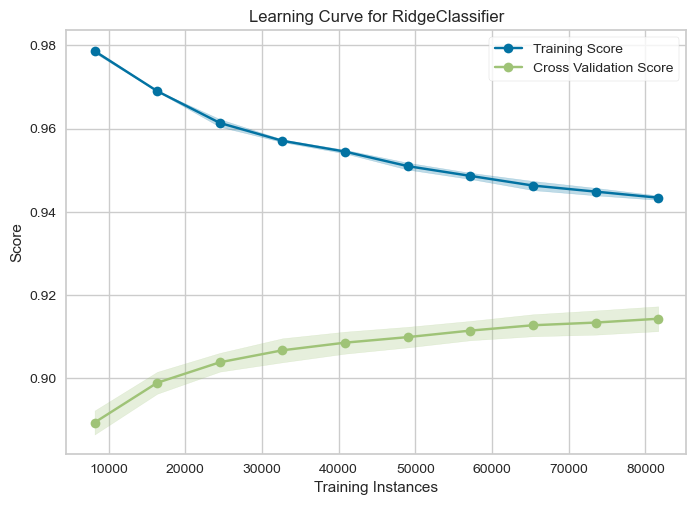

<Axes: title={'center': 'Learning Curve for RidgeClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [95]:
visualizer = LearningCurve(
    best_model, scoring='accuracy', cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
visualizer.fit(X_train, y_train)
visualizer.show()

По графику кривой обучения для оптимизированной модели видим, что кросс-валидационная точность достигает 0.91–0.92 при 80,000+ записей, а разрыв с тренировочной точностью (около 0.03–0.04) указывает на умеренное переобучение. 

Оптимизация гиперпараметров не устранила переобучение, так как лучшие параметры оказались близки к исходным.  

## <hr> 9. С учетом сделанных выводов провести усовершенствование моделей. Это можно осуществить с помощью введения регуляризации, изменение параметров модели (для параметрических моделей), введением суррогатных признаков, отбором признаков, нормализацией данных, ансамблированием моделей, изменением алгоритма предварительной обработки данных. Сравнить результаты.

Преобразуем исходные метки классов из 
```python
[1, 2, 3, 4] в [0, 1, 2, 3]
```


Делаем это из-за того, что `XGBoost` и `RandomForest` требуют метки, начинающиеся с 0, а в датасете метки начинаются с 1. Если этот шаг пропустить, то выскакивает ошибка.

In [181]:
y_train_adjusted = y_train - 1  
y_test_adjusted = y_test - 1    

Используем базовую модель для сравнения с новыми подходами.

In [182]:
tfidf_base = TfidfVectorizer(max_features=10000)
X_train_base = tfidf_base.fit_transform(X_train_text)
X_test_base = tfidf_base.transform(X_test_text)

In [183]:
base_model_default = RidgeClassifier(random_state=42)
base_model_default.fit(X_train_base, y_train)
y_pred_base_default = base_model_default.predict(X_test_base)

In [184]:
print("Метрики на тестовой выборке для исходной модели (из задания 8):")
print(classification_report(y_test, y_pred_base_default, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

Метрики на тестовой выборке для исходной модели (из задания 8):
              precision    recall  f1-score   support

       World       0.93      0.89      0.91      6380
      Sports       0.95      0.99      0.97      6380
    Business       0.88      0.89      0.88      6380
    Sci/Tech       0.89      0.88      0.89      6380

    accuracy                           0.91     25520
   macro avg       0.91      0.91      0.91     25520
weighted avg       0.91      0.91      0.91     25520



Улучшаем предобработку, добавляя биграммы `ngram_range=(1, 2)` и кастомные стоп-слова, чтобы уловить контекст и убрать шум

In [185]:
custom_stop_words = ['reuters', 'ap', 'afp', 'u', 'say', 'said', 'ltbgt', 'inc', 'corp', 'monday', 'tuesday', 'wednesday']
tfidf_enhanced = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), stop_words=custom_stop_words)
X_train_enhanced = tfidf_enhanced.fit_transform(X_train_text)
X_test_enhanced = tfidf_enhanced.transform(X_test_text)

In [186]:
base_model = RidgeClassifier(random_state=42, alpha=1.0, solver='auto', tol=0.01)
base_model.fit(X_train_enhanced, y_train)
y_pred_base = base_model.predict(X_test_enhanced)

In [187]:
print("Метрики на тестовой выборке для модели с биграммами (RidgeClassifier):")
print(classification_report(y_test, y_pred_base, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

Метрики на тестовой выборке для модели с биграммами (RidgeClassifier):
              precision    recall  f1-score   support

       World       0.93      0.90      0.91      6380
      Sports       0.95      0.99      0.97      6380
    Business       0.88      0.89      0.89      6380
    Sci/Tech       0.89      0.89      0.89      6380

    accuracy                           0.92     25520
   macro avg       0.92      0.92      0.92     25520
weighted avg       0.92      0.92      0.92     25520



Также пробуем более сложную модель `XGBoost` с отбором признаков `SVD`, чтобы уменьшить размерность и улучшить качество.

In [188]:
xgb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=15000, ngram_range=(1, 2), stop_words=custom_stop_words)),
    ('svd', TruncatedSVD(random_state=42)),
    ('clf', xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'))
])

In [190]:
param_grid_xgb = {
    'svd__n_components': [500],  
    'clf__max_depth': [6],
    'clf__learning_rate': [0.1],
    'clf__n_estimators': [100]
}

In [191]:
grid_search_xgb = GridSearchCV(xgb_pipeline, param_grid_xgb, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
start_time = time.time()
grid_search_xgb.fit(X_train_text, y_train_adjusted)
end_time = time.time()
fit_time = end_time - start_time

Fitting 3 folds for each of 1 candidates, totalling 3 fits


`+ 1`, чтобы возвратить метки в исходный формат 
``` python
[1, 2, 3, 4]
```

In [192]:
y_pred_xgb = grid_search_xgb.predict(X_test_text) + 1

In [193]:
print(f"Время обучения модели XGBoost с Grid Search: {fit_time:.2f} секунд")
print(f"Лучшие параметры: {grid_search_xgb.best_params_}")
print("Метрики на тестовой выборке для XGBoost:")
print(classification_report(y_test, y_pred_xgb, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

Время обучения модели XGBoost с Grid Search: 163.24 секунд
Лучшие параметры: {'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 100, 'svd__n_components': 500}
Метрики на тестовой выборке для XGBoost:
              precision    recall  f1-score   support

       World       0.89      0.87      0.88      6380
      Sports       0.92      0.96      0.94      6380
    Business       0.85      0.84      0.84      6380
    Sci/Tech       0.85      0.85      0.85      6380

    accuracy                           0.88     25520
   macro avg       0.88      0.88      0.88     25520
weighted avg       0.88      0.88      0.88     25520



Попробуем объединить линейную и нелинейную модели, чтобы улучшить качество за счёт разнообразия

In [194]:
ridge_clf = RidgeClassifier(random_state=42, alpha=1.0, solver='auto', tol=0.01)
rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1, max_depth=10, n_estimators=100)

In [195]:
voting_clf_rf = VotingClassifier(
    estimators=[
        ('ridge', ridge_clf),
        ('rf', rf_clf)
    ],
    voting='hard'
)

In [196]:
tfidf_voting = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), stop_words=custom_stop_words)
X_train_voting = tfidf_voting.fit_transform(X_train_text)
X_test_voting = tfidf_voting.transform(X_test_text)

In [197]:
start_time = time.time()
voting_clf_rf.fit(X_train_voting, y_train_adjusted)
end_time = time.time()
fit_time = end_time - start_time

In [198]:
y_pred_voting_rf = voting_clf_rf.predict(X_test_voting) + 1

In [199]:
print(f"Время обучения ансамблевой модели (Ridge + RandomForest): {fit_time:.2f} секунд")
print("Метрики на тестовой выборке для ансамблевой модели (Ridge + RandomForest):")
print(classification_report(y_test, y_pred_voting_rf, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

Время обучения ансамблевой модели (Ridge + RandomForest): 0.90 секунд
Метрики на тестовой выборке для ансамблевой модели (Ridge + RandomForest):
              precision    recall  f1-score   support

       World       0.84      0.91      0.88      6380
      Sports       0.81      0.97      0.88      6380
    Business       0.83      0.80      0.82      6380
    Sci/Tech       0.92      0.71      0.80      6380

    accuracy                           0.85     25520
   macro avg       0.85      0.85      0.84     25520
weighted avg       0.85      0.85      0.84     25520



В итоге, лучший результат показала модель с биграммами `RidgeClassifier` дала `accuracy = 0.92`, `macro-F1 = 0.92` и `Sci/Tech recall = 0.89`, что на 0.01 лучше исходной модели.

Другие же методы (SVD, ансамблирование) не дали прироста из-за потери информации или переобучения.

## <hr> 10. Попробовать изменить порядок предобработки данных для повышения эффективности модели. Попробовать применить понижение размерности для создания суррогатных признаков. Сравнить результаты, сделать выводы.

In [201]:
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/arinchees/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/arinchees/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [202]:
lemmatizer = WordNetLemmatizer()

In [203]:
def lemmatize_text(text):
    tokens = word_tokenize(text.lower())  
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens] 
    return ' '.join(lemmatized_tokens)

In [205]:
X_train_lemmatized = [lemmatize_text(text) for text in X_train_text]
X_test_lemmatized = [lemmatize_text(text) for text in X_test_text]

Поменяем порядок предобработки и потом воспользуемся SVD для создания суррогатных признаков.

In [206]:
custom_stop_words = ['reuters', 'ap', 'afp', 'u', 'say', 'said', 'ltbgt', 'inc', 'corp', 'monday', 'tuesday', 'wednesday']
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=15000, ngram_range=(1, 2), stop_words=custom_stop_words)),  # Векторизация
    ('svd', TruncatedSVD(n_components=500, random_state=42)),  # Понижение размерности
    ('clf', RidgeClassifier(random_state=42, alpha=1.0, solver='auto', tol=0.01))  # Классификатор
])

In [207]:
start_time = time.time()
pipeline.fit(X_train_lemmatized, y_train)  
end_time = time.time()
fit_time = end_time - start_time

In [208]:
y_pred_lemmatized = pipeline.predict(X_test_lemmatized)

In [209]:
print(f"Время обучения модели с лемматизацией и SVD: {fit_time:.2f} секунд")
print("Метрики на тестовой выборке для модели с лемматизацией и SVD (RidgeClassifier):")
print(classification_report(y_test, y_pred_lemmatized, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

Время обучения модели с лемматизацией и SVD: 28.60 секунд
Метрики на тестовой выборке для модели с лемматизацией и SVD (RidgeClassifier):
              precision    recall  f1-score   support

       World       0.91      0.87      0.89      6380
      Sports       0.92      0.97      0.95      6380
    Business       0.85      0.86      0.86      6380
    Sci/Tech       0.87      0.85      0.86      6380

    accuracy                           0.89     25520
   macro avg       0.89      0.89      0.89     25520
weighted avg       0.89      0.89      0.89     25520



In [210]:
print("Метрики на тестовой выборке для лучшей модели из задания 9 (с биграммами):")
print(classification_report(y_test, y_pred_base, target_names=['World', 'Sports', 'Business', 'Sci/Tech']))

Метрики на тестовой выборке для лучшей модели из задания 9 (с биграммами):
              precision    recall  f1-score   support

       World       0.93      0.90      0.91      6380
      Sports       0.95      0.99      0.97      6380
    Business       0.88      0.89      0.89      6380
    Sci/Tech       0.89      0.89      0.89      6380

    accuracy                           0.92     25520
   macro avg       0.92      0.92      0.92     25520
weighted avg       0.92      0.92      0.92     25520



Имеем, что изменение порядка предобработки (добавление лемматизации) и применение понижения размерности через `TruncatedSVD` для создания суррогатных признаков не повысило эффективность модели. Напротив, `accuracy` упала с 0.92 до 0.89 из-за потери информации и избыточности лемматизации. 

Лучшей моделью осталась `RidgeClassifier` с биграммами.

## <hr> 11. Представить результаты моделирования в наглядном виде (графики, линии обучения, таблицы сравнения моделей, таблицы классификации, и другие). Сделать выводы, сравнить с существующими аналогичными решениями, порассуждать о перспективах решения проблемы.


In [213]:
models = ['Baseline', 'Bigrams', 'XGBoost with SVD', 
          'Ensemble', 'Lemmatized with SVD']
accuracy = [0.91, 0.92, 0.88, 0.85, 0.89]
macro_f1 = [0.91, 0.92, 0.88, 0.84, 0.89]
sci_tech_recall = [0.88, 0.89, 0.85, 0.71, 0.85]

In [214]:
comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Macro F1': macro_f1,
    'Sci/Tech Recall': sci_tech_recall
})

comparison_df

,Model,Accuracy,Macro F1,Sci/Tech Recall
0,Baseline,0.91,0.91,0.88
1,Bigrams,0.92,0.92,0.89
2,XGBoost with SVD,0.88,0.88,0.85
3,Ensemble,0.85,0.84,0.71
4,Lemmatized with SVD,0.89,0.89,0.85


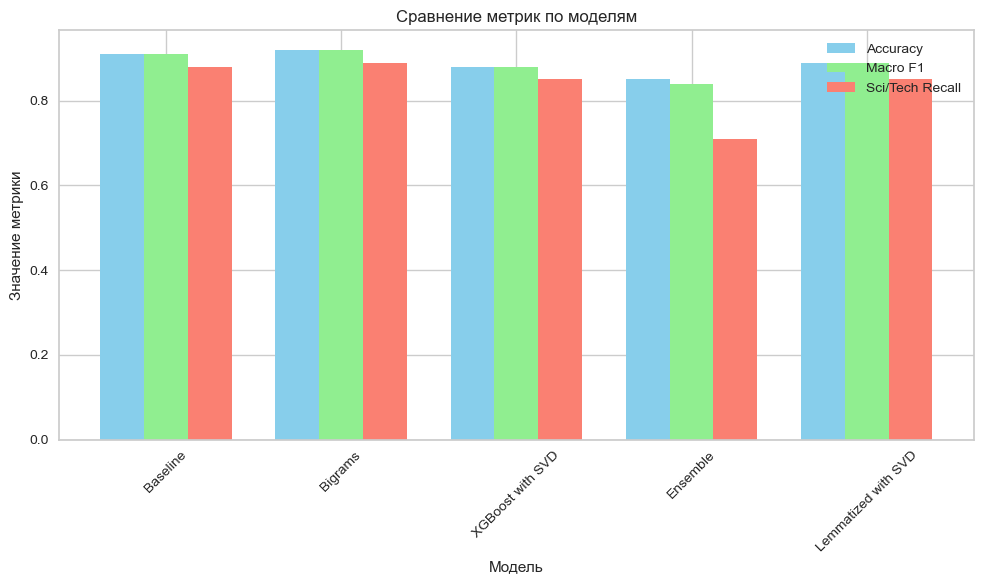

In [215]:
plt.figure(figsize=(10, 6))
bar_width = 0.25
index = np.arange(len(models))

plt.bar(index, accuracy, bar_width, label='Accuracy', color='skyblue')
plt.bar(index + bar_width, macro_f1, bar_width, label='Macro F1', color='lightgreen')
plt.bar(index + 2 * bar_width, sci_tech_recall, bar_width, label='Sci/Tech Recall', color='salmon')

plt.xlabel('Модель')
plt.ylabel('Значение метрики')
plt.title('Сравнение метрик по моделям')
plt.xticks(index + bar_width, models, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Модель `bigrams` имеет самые высокие значения по всем трём метрикам, а `Ensemble` имеет наименьшие значения.

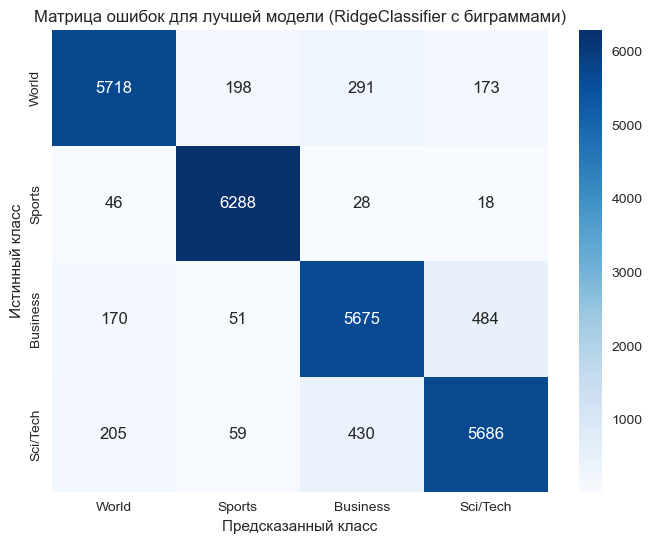

In [217]:
y_pred_best = y_pred_base  
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['World', 'Sports', 'Business', 'Sci/Tech'],
             yticklabels=['World', 'Sports', 'Business', 'Sci/Tech'])
plt.title('Матрица ошибок для лучшей модели (RidgeClassifier с биграммами)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

На матрице видно, что сновные ошибки происходят между `Business` и `Sci/Tech`.

Подводя итоги, наилучшей моделью оказалась модель с биграммами (`RidgeClassifier`), ее `accuracy`, `f1-macro`, `Sci/Tech recall` повысились на 0.01.

## <hr> Выводы

В данной работе рассматривалась классификация текстов датасета `AG News` базовой модели (`RidgeClassifier`, `accuracy = 0.91`), которая была улучшена через предобработку, регуляризацию, ансамблирование и понижение размерности. По итогу, лучший результат показала модель с биграммами (`RidgeClassifier`, `accuracy = 0.92`), что было  подтверждено числовыми метриками и визуальным анализом.